# Cross-case 2D--3D distributional disagreement

This notebook plots the manually entered IQR-normalized Wasserstein distance, $W_1^*$, against the selected snapshot times for the vorticity and strain-rate distributions

In [25]:

# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import json
import importlib
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable

NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"
RESULTS_ROOT = FLOW_DIR / "results"

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()

importlib.reload(shu)
shu.apply_plot_style()
from shcherbina_utils import _theme_attr


def apply_cross_case_style():
    shu.apply_plot_style()
    plt.rcParams.update({
        "font.size": max(getattr(ptheme, "FONT_SIZE", 14), 19),
        "axes.titlesize": max(getattr(ptheme, "TITLE_SIZE", 20), 24),
        "axes.labelsize": max(getattr(ptheme, "LABEL_SIZE", 18), 22),
        "xtick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 18),
        "ytick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 18),
        "legend.fontsize": max(getattr(ptheme, "LEGEND_SIZE", 15), 17),
        "figure.titlesize": max(getattr(ptheme, "SUPTITLE_SIZE", 24), 27),
    })


apply_cross_case_style()

print(f"Notebook dir : {NB_DIR}")
print(f"Results root : {RESULTS_ROOT}")


Notebook dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Results root : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results


In [26]:
SELECTED_TIMES = np.array([0.0, 3.0, 7.0, 13.0])

# All cases considered in the cross-case comparison
CASE_NAMES = [
    "run_aug1",
    "run_aug1_f1",
    "run_aug1_f2",
    "run_aug2",
    "run_aug3",
    "run_dec1",
    "run_dec2",
    "run_feb1",
    "run_jan1",
    "run_jul1",
    "run_jun1",
    "run_mar1",
    "run_may1",
    "run_nov1",
    "run_oct1",
    "run_sep1",
]

# IDEE: ALLE CASES IN EEN DICT MET LABELS EN KLEUREN, EN DAN VERDELEN IN 2 KLEURGROEPEN OBV TOT HOE DIEP ZE GAAN
# EN AANTAL LAGEN VISUALISEREN MET TINT KLEUR

# These cases are excluded from the boxplots and plotted individually.
# The label, colour and marker can be set manually.
HIGHLIGHT_CASES = {
    "run_aug1": {
        "label": "AUG-1",
        "color": "tab:blue",
        "marker": "^",
    },
}

# Set to False when only individual points are desired.
CONNECT_HIGHLIGHTED_CASES = False
SAVE_SUMMARY_CSV = False

In [27]:

# ============================================================
# 3. W1* VALUES
# ============================================================

W1_STAR_VALUES = {
    case_name: {
        "vorticity": {day: np.nan for day in SELECTED_TIMES},
        "strain": {day: np.nan for day in SELECTED_TIMES},
    }
    for case_name in CASE_NAMES
}


W1_STAR_VALUES["run_aug1"]["vorticity"].update({
    0.0: 0.031,
    3.0: 0.051,
    7.0: 0.087,
    13.0: 0.099,
})

W1_STAR_VALUES["run_aug1"]["strain"].update({
    0.0: 0.052,
    3.0: 0.126,
    7.0: 0.113,
    13.0: 0.154,
})

# W1_STAR_VALUES["run_aug1_v18"]["vorticity"].update({
#     0.0: 0.078,
#     3.0: 0.095,
#     7.0: 0.090,
#     13.0: 0.102,
# })

# W1_STAR_VALUES["run_aug1_v18"]["strain"].update({
#     0.0: 0.118,
#     3.0: 0.146,
#     7.0: 0.182,
#     13.0: 0.186,
# })


# W1_STAR_VALUES["run_aug1_v24"]["vorticity"].update({
#     0.0: 0.050,
#     3.0: 0.052,
#     7.0: 0.050,
#     13.0: 0.055,
# })

# W1_STAR_VALUES["run_aug1_v24"]["strain"].update({
#     0.0: 0.066,
#     3.0: 0.073,
#     7.0: 0.096,
#     13.0: 0.094,
# })


# W1_STAR_VALUES["run_aug1_v30"]["vorticity"].update({
#     0.0: 0.044,
#     3.0: 0.045,
#     7.0: 0.033,
#     13.0: 0.046,
# })

# W1_STAR_VALUES["run_aug1_v30"]["strain"].update({
#     0.0: 0.054,
#     3.0: 0.051,
#     7.0: 0.051,
#     13.0: 0.059,
# })


# W1_STAR_VALUES["run_aug1_v36"]["vorticity"].update({
#     0.0: 0.038,
#     3.0: 0.038,
#     7.0: 0.028,
#     13.0: 0.035,
# })

# W1_STAR_VALUES["run_aug1_v36"]["strain"].update({
#     0.0: 0.047,
#     3.0: 0.043,
#     7.0: 0.044,
#     13.0: 0.052,
# })


# W1_STAR_VALUES["run_aug1_v42"]["vorticity"].update({
#     0.0: 0.014,
#     3.0: 0.016,
#     7.0: 0.036,
#     13.0: 0.026,
# })

# W1_STAR_VALUES["run_aug1_v42"]["strain"].update({
#     0.0: 0.020,
#     3.0: 0.032,
#     7.0: 0.067,
#     13.0: 0.035,
# })


W1_STAR_VALUES["run_aug1_f1"]["vorticity"].update({
    0.0: 0.021,
    3.0: 0.090,
    7.0: 0.155,
    13.0: 0.198,
})

W1_STAR_VALUES["run_aug1_f1"]["strain"].update({
    0.0: 0.036,
    3.0: 0.140,
    7.0: 0.218,
    13.0: 0.278,
})


W1_STAR_VALUES["run_aug1_f2"]["vorticity"].update({
    0.0: 0.034,
    3.0: 0.045,
    7.0: 0.047,
    13.0: 0.034,
})

W1_STAR_VALUES["run_aug1_f2"]["strain"].update({
    0.0: 0.066,
    3.0: 0.038,
    7.0: 0.074,
    13.0: 0.074,
})


W1_STAR_VALUES["run_aug2"]["vorticity"].update({
    0.0: 0.031,
    3.0: 0.124,
    7.0: 0.238,
    13.0: 0.264,
})

W1_STAR_VALUES["run_aug2"]["strain"].update({
    0.0: 0.078,
    3.0: 0.351,
    7.0: 0.439,
    13.0: 0.460,
})


W1_STAR_VALUES["run_aug3"]["vorticity"].update({
    0.0: 0.000,
    3.0: 0.042,
    7.0: 0.044,
    13.0: 0.035,
})

W1_STAR_VALUES["run_aug3"]["strain"].update({
    0.0: 0.000,
    3.0: 0.734,
    7.0: 0.758,
    13.0: 0.829,
})


W1_STAR_VALUES["run_dec1"]["vorticity"].update({
    0.0: 0.009,
    3.0: 0.087,
    7.0: 0.108,
    13.0: 0.132,
})

W1_STAR_VALUES["run_dec1"]["strain"].update({
    0.0: 0.011,
    3.0: 0.079,
    7.0: 0.027,
    13.0: 0.041,
})


W1_STAR_VALUES["run_dec2"]["vorticity"].update({
    0.0: 0.000,
    3.0: 0.070,
    7.0: 0.077,
    13.0: 0.099,
})

W1_STAR_VALUES["run_dec2"]["strain"].update({
    0.0: 0.000,
    3.0: 0.050,
    7.0: 0.026,
    13.0: 0.019,
})


W1_STAR_VALUES["run_feb1"]["vorticity"].update({
    0.0: 0.013,
    3.0: 0.120,
    7.0: 0.140,
    13.0: 0.170,
})

W1_STAR_VALUES["run_feb1"]["strain"].update({
    0.0: 0.006,
    3.0: 0.296,
    7.0: 0.361,
    13.0: 0.449,
})


W1_STAR_VALUES["run_jan1"]["vorticity"].update({
    0.0: 0.011,
    3.0: 0.162,
    7.0: 0.212,
    13.0: 0.220,
})

W1_STAR_VALUES["run_jan1"]["strain"].update({
    0.0: 0.010,
    3.0: 0.156,
    7.0: 0.257,
    13.0: 0.303,
})


W1_STAR_VALUES["run_jul1"]["vorticity"].update({
    0.0: 0.026,
    3.0: 0.051,
    7.0: 0.080,
    13.0: 0.084,
})

W1_STAR_VALUES["run_jul1"]["strain"].update({
    0.0: 0.051,
    3.0: 0.156,
    7.0: 0.197,
    13.0: 0.193,
})


W1_STAR_VALUES["run_jun1"]["vorticity"].update({
    0.0: 0.000,
    3.0: 0.076,
    7.0: 0.109,
    13.0: 0.120,
})

W1_STAR_VALUES["run_jun1"]["strain"].update({
    0.0: 0.000,
    3.0: 0.157,
    7.0: 0.281,
    13.0: 0.207,
})


W1_STAR_VALUES["run_mar1"]["vorticity"].update({
    0.0: 0.004,
    3.0: 0.084,
    7.0: 0.099,
    13.0: 0.118,
})

W1_STAR_VALUES["run_mar1"]["strain"].update({
    0.0: 0.006,
    3.0: 0.085,
    7.0: 0.103,
    13.0: 0.117,
})


W1_STAR_VALUES["run_may1"]["vorticity"].update({
    0.0: 0.034,
    3.0: 0.063,
    7.0: 0.078,
    13.0: 0.088,
})

W1_STAR_VALUES["run_may1"]["strain"].update({
    0.0: 0.044,
    3.0: 0.113,
    7.0: 0.110,
    13.0: 0.071,
})


W1_STAR_VALUES["run_nov1"]["vorticity"].update({
    0.0: 0.029,
    3.0: 0.042,
    7.0: 0.122,
    13.0: 0.149,
})

W1_STAR_VALUES["run_nov1"]["strain"].update({
    0.0: 0.025,
    3.0: 0.297,
    7.0: 0.331,
    13.0: 0.362,
})


W1_STAR_VALUES["run_oct1"]["vorticity"].update({
    0.0: 0.083,
    3.0: 0.087,
    7.0: 0.088,
    13.0: 0.112,
})

W1_STAR_VALUES["run_oct1"]["strain"].update({
    0.0: 0.059,
    3.0: 0.297,
    7.0: 0.295,
    13.0: 0.327,
})


W1_STAR_VALUES["run_sep1"]["vorticity"].update({
    0.0: 0.053,
    3.0: 0.064,
    7.0: 0.110,
    13.0: 0.144,
})

W1_STAR_VALUES["run_sep1"]["strain"].update({
    0.0: 0.032,
    3.0: 0.242,
    7.0: 0.330,
    13.0: 0.421,
})

In [28]:
# ============================================================
# 4. INPUT HELPERS
# ============================================================

def _as_finite_float(value):
    """Convert a value to a finite float; otherwise return NaN."""
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan

    return value if np.isfinite(value) else np.nan


def get_w1_value(case_name, diagnostic, time_day):
    """Return one manually entered W1* value."""
    diagnostic_values = (
        W1_STAR_VALUES
        .get(case_name, {})
        .get(diagnostic, {})
    )

    # Match numerically so that integer and floating-point keys both work.
    for stored_time, value in diagnostic_values.items():
        try:
            matches = np.isclose(
                float(stored_time),
                float(time_day),
            )
        except (TypeError, ValueError):
            continue

        if matches:
            return _as_finite_float(value)

    return np.nan


def _get_w1_series(case_name, diagnostic, selected_times):
    """Return W1* values for one case at the selected snapshots."""
    return np.asarray(
        [
            get_w1_value(case_name, diagnostic, time_day)
            for time_day in selected_times
        ],
        dtype=float,
    )


def get_case_display_name(case_name, highlight_cases=None):
    """Return the manually specified legend label when available."""
    if highlight_cases and case_name in highlight_cases:
        return highlight_cases[case_name].get("label", case_name)

    return case_name

In [29]:
# ============================================================
# 5. BUILD THE CROSS-CASE TABLE
# ============================================================

if "INCLUDED_CASES" in globals():
    included_cases = list(INCLUDED_CASES)
elif "CASE_NAMES" in globals():
    included_cases = list(CASE_NAMES)
else:
    raise NameError("Define INCLUDED_CASES or CASE_NAMES first.")

if "SELECTED_TIMES" in globals():
    selected_times = np.asarray(SELECTED_TIMES, dtype=float)
elif "SNAPSHOT_DAYS" in globals():
    selected_times = np.asarray(SNAPSHOT_DAYS, dtype=float)
else:
    raise NameError("Define SELECTED_TIMES or SNAPSHOT_DAYS first.")


records = []
missing_w1_values = []

for case_name in included_cases:
    is_highlighted = case_name in HIGHLIGHT_CASES

    for diagnostic in ("vorticity", "strain"):
        for time_day in selected_times:
            value = get_w1_value(
                case_name,
                diagnostic,
                time_day,
            )

            if not np.isfinite(value):
                missing_w1_values.append(
                    f"{case_name}: {diagnostic}, "
                    f"T={time_day:g} d"
                )

            records.append({
                "case_3d": case_name,
                "display_name": get_case_display_name(
                    case_name,
                    HIGHLIGHT_CASES,
                ),
                "diagnostic": diagnostic,
                "time_days": float(time_day),
                "w1_star": value,
                "is_highlighted": is_highlighted,
            })


w1_df = (
    pd.DataFrame(records)
    .sort_values(
        ["diagnostic", "case_3d", "time_days"]
    )
    .reset_index(drop=True)
)

display(w1_df)


if missing_w1_values:
    print("\nMissing manually entered W1* values:")
    for message in dict.fromkeys(missing_w1_values):
        print(f"  - {message}")


valid_count = int(w1_df["w1_star"].notna().sum())

print(
    f"\nValid W1* values entered: "
    f"{valid_count} / {len(w1_df)}"
)

print(
    f"Cases included in boxplots: "
    f"{sum(case not in HIGHLIGHT_CASES for case in included_cases)}"
)

print(
    f"Highlighted cases: "
    f"{sum(case in HIGHLIGHT_CASES for case in included_cases)}"
)


if SAVE_SUMMARY_CSV:
    csv_path = OUTPUT_DIR / "cross_case_w1star_summary.csv"
    w1_df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

,case_3d,display_name,diagnostic,time_days,w1_star,is_highlighted
0,run_aug1,AUG-1,strain,0.0,0.052,True
1,run_aug1,AUG-1,strain,3.0,0.126,True
2,run_aug1,AUG-1,strain,7.0,0.113,True
3,run_aug1,AUG-1,strain,13.0,0.154,True
4,run_aug1_f1,run_aug1_f1,strain,0.0,0.036,False
...,...,...,...,...,...,...
123,run_oct1,run_oct1,vorticity,13.0,0.112,False
124,run_sep1,run_sep1,vorticity,0.0,0.053,False
125,run_sep1,run_sep1,vorticity,3.0,0.064,False
126,run_sep1,run_sep1,vorticity,7.0,0.110,False



Valid W1* values entered: 128 / 128
Cases included in boxplots: 15
Highlighted cases: 1


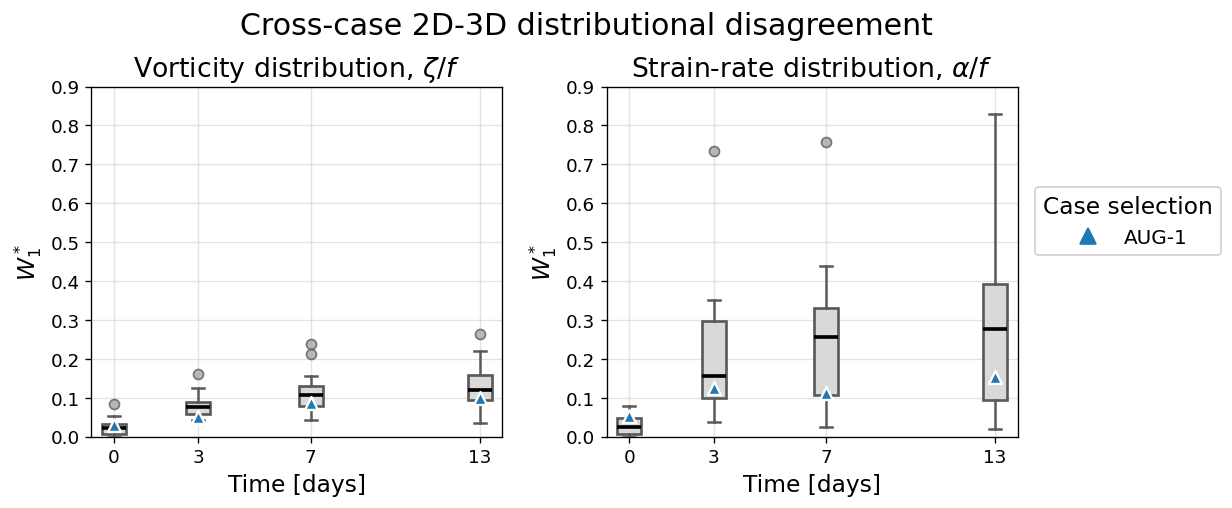

In [30]:
# ============================================================
# 6. CROSS-CASE W1* BOXPLOTS
# ============================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def plot_cross_case_w1_boxplots(
    included_cases,
    highlight_cases,
    selected_times=SELECTED_TIMES,
    figsize=None,
):
    """
    Plot cross-case W1* boxplots at the selected snapshots.

    Highlighted cases are excluded from the boxplot statistics and
    displayed separately as coloured markers without connecting lines.
    """
    shu.apply_plot_style()

    if figsize is None:
        figsize = shu.get_figsize("wide")

    selected_times = np.asarray(selected_times, dtype=float)

    boxplot_cases = [
        case_name
        for case_name in included_cases
        if case_name not in highlight_cases
    ]

    highlighted_cases = [
        case_name
        for case_name in highlight_cases
        if case_name in included_cases
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        sharey=False,
        facecolor="white",
    )

    diagnostic_settings = [
        ("vorticity", r"Vorticity distribution, $\zeta/f$"),
        ("strain", r"Strain-rate distribution, $\alpha/f$"),
    ]

    missing_entries = []

    for ax, (diagnostic, panel_title) in zip(
        axes,
        diagnostic_settings,
    ):
        ax.set_facecolor("white")

        # --------------------------------------------------------
        # Boxplots: all non-highlighted cases
        # --------------------------------------------------------
        boxplot_values = []
        boxplot_positions = []

        for time_day in selected_times:
            values_at_time = []

            for case_name in boxplot_cases:
                value = get_w1_value(
                    case_name,
                    diagnostic,
                    time_day,
                )

                if np.isfinite(value):
                    values_at_time.append(value)
                else:
                    missing_entries.append(
                        (case_name, diagnostic, time_day)
                    )

            if values_at_time:
                boxplot_values.append(values_at_time)
                boxplot_positions.append(float(time_day))

        if boxplot_values:
            ax.boxplot(
                boxplot_values,
                positions=boxplot_positions,
                widths=0.85,
                patch_artist=True,
                manage_ticks=False,
                showfliers=True,
                medianprops={
                    "color": "black",
                    "linewidth": 2.2,
                },
                boxprops={
                    "facecolor": "0.85",
                    "edgecolor": "0.35",
                    "linewidth": 1.6,
                },
                whiskerprops={
                    "color": "0.35",
                    "linewidth": 1.5,
                },
                capprops={
                    "color": "0.35",
                    "linewidth": 1.5,
                },
                flierprops={
                    "marker": "o",
                    "markerfacecolor": "0.65",
                    "markeredgecolor": "0.35",
                    "markersize": 6,
                    "alpha": 0.8,
                },
            )

        # --------------------------------------------------------
        # Highlighted cases: markers only
        # --------------------------------------------------------
        if len(highlighted_cases) > 1:
            offsets = np.linspace(
                -0.25,
                0.25,
                len(highlighted_cases),
            )
        else:
            offsets = np.zeros(len(highlighted_cases))

        for offset, case_name in zip(
            offsets,
            highlighted_cases,
        ):
            style = highlight_cases[case_name]

            series = _get_w1_series(
                case_name,
                diagnostic,
                selected_times,
            )

            finite = np.isfinite(series)
            shifted_times = selected_times + offset

            for missing_time in selected_times[~finite]:
                missing_entries.append(
                    (case_name, diagnostic, missing_time)
                )

            ax.scatter(
                shifted_times[finite],
                series[finite],
                color=style["color"],
                marker=style.get("marker", "o"),
                s=60,
                edgecolor="white",
                linewidth=1.4,
                zorder=5,
            )

        shu.format_axis(
            ax,
            title=panel_title,
            xlabel="Time [days]",
            ylabel=r"$W_1^*$",
            grid=True,
        )

        ax.set_xticks(selected_times)
        ax.set_xlim(
            selected_times.min() - 0.8,
            selected_times.max() + 0.8,
        )

        # Independent vertical scale for each diagnostic.
        diagnostic_values = []

        for case_name in included_cases:
            series = _get_w1_series(
                case_name,
                diagnostic,
                selected_times,
            )
            diagnostic_values.extend(
                series[np.isfinite(series)]
            )

        if diagnostic_values:
            upper_limit = max(diagnostic_values) * 1.10
            upper_limit = 0.9
            ax.set_ylim(
                0.0,
                upper_limit if upper_limit > 0 else 1.0,
            )

    # ------------------------------------------------------------
    # Legend outside the two panels
    # ------------------------------------------------------------
    legend_handles = [
    ]

    for case_name in highlighted_cases:
        style = highlight_cases[case_name]

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=style["color"],
                marker=style.get("marker", "o"),
                linestyle="None",
                markersize=10,
                label=style.get("label", case_name),
            )
        )

    fig.suptitle(
        "Cross-case 2D-3D distributional disagreement",
        fontsize=_theme_attr("SUPTITLE_SIZE", 18),
        y=0.85,   # lower the title slightly
    )

    # Leave a bit less space on the right, and a bit more room for the title
    fig.tight_layout(
        rect=[0.0, 0.0, 0.88, 0.91]
    )

    fig.legend(
        handles=legend_handles,
        title="Case selection",
        loc="center left",
        bbox_to_anchor=(0.865, 0.50),   # move legend closer to right panel
        frameon=True,
    )

    if missing_entries:
        print("\nMissing W1* values used by the plot:")

        for case_name, diagnostic, time_day in sorted(
            set(missing_entries)
        ):
            print(
                f"  - {case_name}: {diagnostic}, "
                f"T={time_day:g} days"
            )

    return fig, axes


fig, axes = plot_cross_case_w1_boxplots(
    included_cases=included_cases,
    highlight_cases=HIGHLIGHT_CASES,
    selected_times=selected_times,
)

plt.show()